In [2]:
# Mount Google Drive and setup project environment
from google.colab import drive
drive.mount("/content/drive")

import warnings
warnings.filterwarnings("ignore")

# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Mounted at /content/drive


In [3]:
# Define project paths and load raw data from Drive
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/DATA6545/"
PROJECT_PATH = BASE_PATH + "allstate_project/"

train = pd.read_csv(PROJECT_PATH + "data/raw/train.csv")
test = pd.read_csv(PROJECT_PATH + "data/raw/test.csv")

print("Train:", train.shape)
print("Test:", test.shape)

Train: (188318, 132)
Test: (125546, 131)


In [4]:
# Identify target and separate categorical vs. continuous features
# 'Cat' = categorical, 'cont' = continuous
target = "loss"
cat_cols = [c for c in train.columns if c.startswith("cat")]
num_cols = [c for c in train.columns if c.startswith("cont")]
feature_cols = cat_cols + num_cols
# Log-transform target to reduce right-skew
train["log_loss"] = np.log1p(train["loss"])

In [5]:
# label encode all categorical features using combined train+test
# Fitting on combined data ensures both splits share the same integer mapping
combined = pd.concat([train[feature_cols], test[feature_cols]], axis=0)

for col in cat_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))
# Split back into train and test after encoding
X = combined.iloc[:len(train)].copy()
X_test = combined.iloc[len(train):].copy()

y = train["log_loss"]

In [6]:
# 80/20 holdout split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Inverse-transform validation labels for dollar scale evaluation
y_valid_actual = np.expm1(y_valid)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)

Train: (150654, 130)
Valid: (37664, 130)


In [7]:
# Install LightGBM - gradient boosted trees
!pip install lightgbm --quiet
import lightgbm as lgb

In [8]:
# LightGBM regressor with early stopping on validation MAE
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
              n_estimators=1000, n_jobs=-1, num_leaves=63, random_state=42,
              subsample=0.8, verbose=-1)

In [9]:
# Predict on validation set and inverse-transform back to dollar scale
lgb_pred_log = lgb_model.predict(X_valid)
lgb_pred = np.expm1(lgb_pred_log)

lgb_mae = mean_absolute_error(y_valid_actual, lgb_pred)
lgb_rmse = np.sqrt(mean_squared_error(y_valid_actual, lgb_pred))
lgb_r2 = r2_score(y_valid_actual, lgb_pred)

print("LightGBM MAE:", round(lgb_mae, 2))
print("LightGBM RMSE:", round(lgb_rmse, 2))
print("LightGBM R2:", round(lgb_r2, 4))

LightGBM MAE: 1135.16
LightGBM RMSE: 1895.83
LightGBM R2: 0.5595


In [10]:
# 5-fold CV to confirm holdout results generalize across different data splits
# Manual loop used to capture per-fold metrics and train MAE for overfit detection
from sklearn.model_selection import KFold
import time

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_maes = []
fold_r2s = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    t0 = time.time()

    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    m = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    m.fit(X_tr, y_tr)

    preds = np.expm1(m.predict(X_val))
    actual = np.expm1(y_val)

    mae = mean_absolute_error(actual, preds)
    r2 = r2_score(actual, preds)
    fold_maes.append(mae)
    fold_r2s.append(r2)

    print(f"Fold {fold+1} | MAE: {round(mae,2)} | R2: {round(r2,4)} | Time: {round(time.time()-t0,1)}s")

print()
print("Mean MAE:", round(np.mean(fold_maes), 2))
print("Std MAE: ", round(np.std(fold_maes), 2))
print("Mean R2: ", round(np.mean(fold_r2s), 4))

Fold 1 | MAE: 1136.85 | R2: 0.5589 | Time: 46.5s
Fold 2 | MAE: 1157.15 | R2: 0.53 | Time: 19.7s
Fold 3 | MAE: 1150.27 | R2: 0.5611 | Time: 19.2s
Fold 4 | MAE: 1148.42 | R2: 0.5663 | Time: 23.6s
Fold 5 | MAE: 1136.85 | R2: 0.5435 | Time: 19.7s

Mean MAE: 1145.91
Std MAE:  7.95
Mean R2:  0.5519


In [11]:
# Persist trained LightGBM regressor to disk for API deployment use
joblib.dump(lgb_model, PROJECT_PATH + "models/lgbm_regressor.joblib")
print("Model saved.")

Model saved.


In [12]:
# Define high-severity claims as the top 10% by loss value
threshold = train["loss"].quantile(0.90)
print("High severity threshold (90th percentile):", round(threshold, 2))

y_clf = (train["loss"] >= threshold).astype(int)
print("High severity claims:", y_clf.sum())
print("Normal claims:", (y_clf == 0).sum())
print("% high severity:", round(y_clf.mean() * 100, 1))

High severity threshold (90th percentile): 6401.74
High severity claims: 18832
Normal claims: 169486
% high severity: 10.0


In [13]:
# Stratified split preserves the 10/90 class ratio in both train and validation
from sklearn.model_selection import train_test_split as tts

X_tr_clf, X_val_clf, y_tr_clf, y_val_clf = tts(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train positives:", y_tr_clf.sum())
print("Valid positives:", y_val_clf.sum())

Train positives: 15066
Valid positives: 3766


In [14]:
# Binary classifier to flag claims likely to exceed the 90th percentile threshold
# Useful for triage - allows early routing of high-cost claims
clf_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

clf_model.fit(X_tr_clf, y_tr_clf)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
               n_estimators=500, n_jobs=-1, num_leaves=63, random_state=42,
               subsample=0.8, verbose=-1)

AUC-ROC: 0.9315

Optimal threshold (Youden's J): 0.0746
Optimal threshold (max F1):     0.2760

--- Default 0.5 threshold ---
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     33898
           1       0.72      0.47      0.57      3766

    accuracy                           0.93     37664
   macro avg       0.83      0.73      0.77     37664
weighted avg       0.92      0.93      0.92     37664

--- Optimal threshold (0.07) ---
              precision    recall  f1-score   support

           0       0.98      0.82      0.90     33898
           1       0.36      0.88      0.51      3766

    accuracy                           0.83     37664
   macro avg       0.67      0.85      0.70     37664
weighted avg       0.92      0.83      0.86     37664



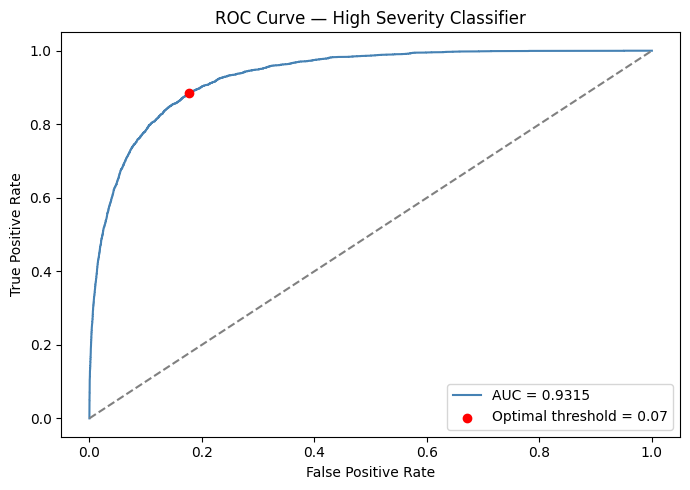

In [15]:
# AUC-ROC
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, f1_score
import matplotlib.pyplot as plt

clf_probs = clf_model.predict_proba(X_val_clf)[:, 1]

auc = roc_auc_score(y_val_clf, clf_probs)
print("AUC-ROC:", round(auc, 4))

# Find optimal threshold using Youden's J statistic (maximizes sensitivity + specificity)
fpr, tpr, thresholds = roc_curve(y_val_clf, clf_probs)
youden_j = tpr - fpr
optimal_idx = youden_j.argmax()
optimal_threshold = thresholds[optimal_idx]
print(f"\nOptimal threshold (Youden's J): {optimal_threshold:.4f}")

# Finding threshold that maximizes F1
f1_scores = [f1_score(y_val_clf, (clf_probs >= t).astype(int)) for t in thresholds]
best_f1_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold (max F1):     {best_f1_threshold:.4f}")

# Apply optimal threshold and compare to default 0.5
print("\n--- Default 0.5 threshold ---")
print(classification_report(y_val_clf, (clf_probs >= 0.5).astype(int)))

print(f"--- Optimal threshold ({optimal_threshold:.2f}) ---")
clf_preds = (clf_probs >= optimal_threshold).astype(int)
print(classification_report(y_val_clf, clf_preds))

# Capture optimal threshold metrics for MLflow logging
report_optimal = classification_report(y_val_clf, clf_preds, output_dict=True)
clf_precision_opt = report_optimal["1"]["precision"]
clf_recall_opt    = report_optimal["1"]["recall"]
clf_f1_opt        = report_optimal["1"]["f1-score"]

# Plot ROC curve with optimal threshold
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="steelblue", label=f"AUC = {auc:.4f}")
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color="red", zorder=5,
            label=f"Optimal threshold = {optimal_threshold:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — High Severity Classifier")
plt.legend()
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# Persist classifier with regression for Flask API
joblib.dump(clf_model, PROJECT_PATH + "models/lgbm_classifier.joblib")
print("Classifier saved.")

Classifier saved.


In [17]:
# Install SHAP for model interpretability
!pip install shap --quiet
import shap

In [18]:
# Compute SHAP values for the validation set using trained regressor
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_valid)

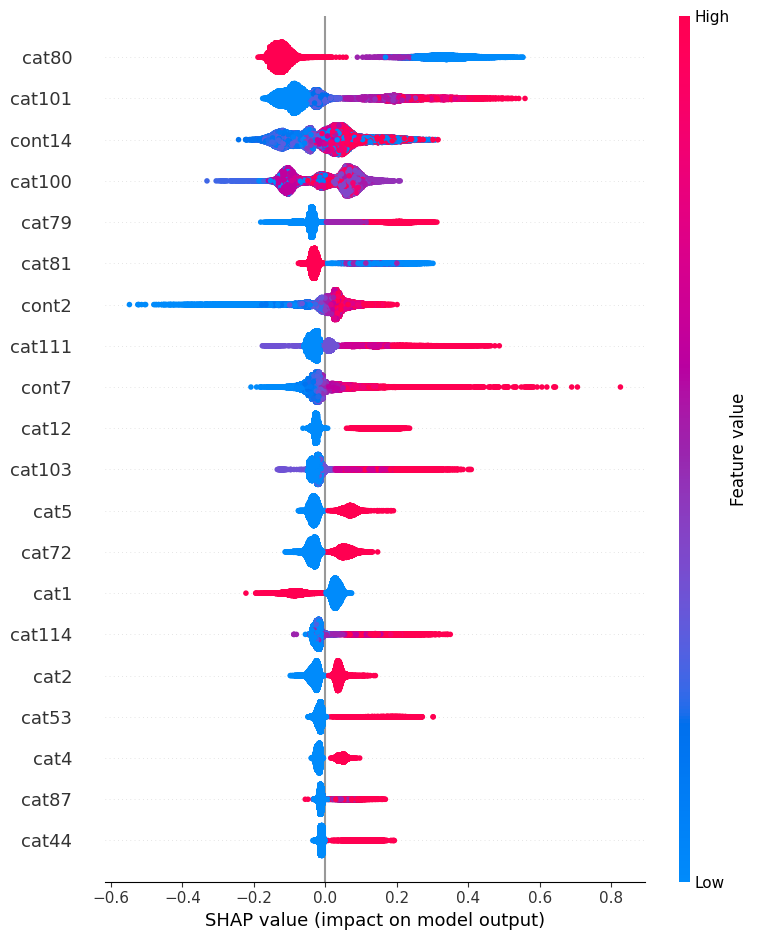

In [19]:
# Dot plot - each point is one predictio, color = feature value
# Shows both direction and magnitude of each features impact on loss
plt.figure()
shap.summary_plot(shap_values, X_valid, max_display=20, show=False)
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/shap_summary_dot.png", dpi=150, bbox_inches="tight")
plt.show()

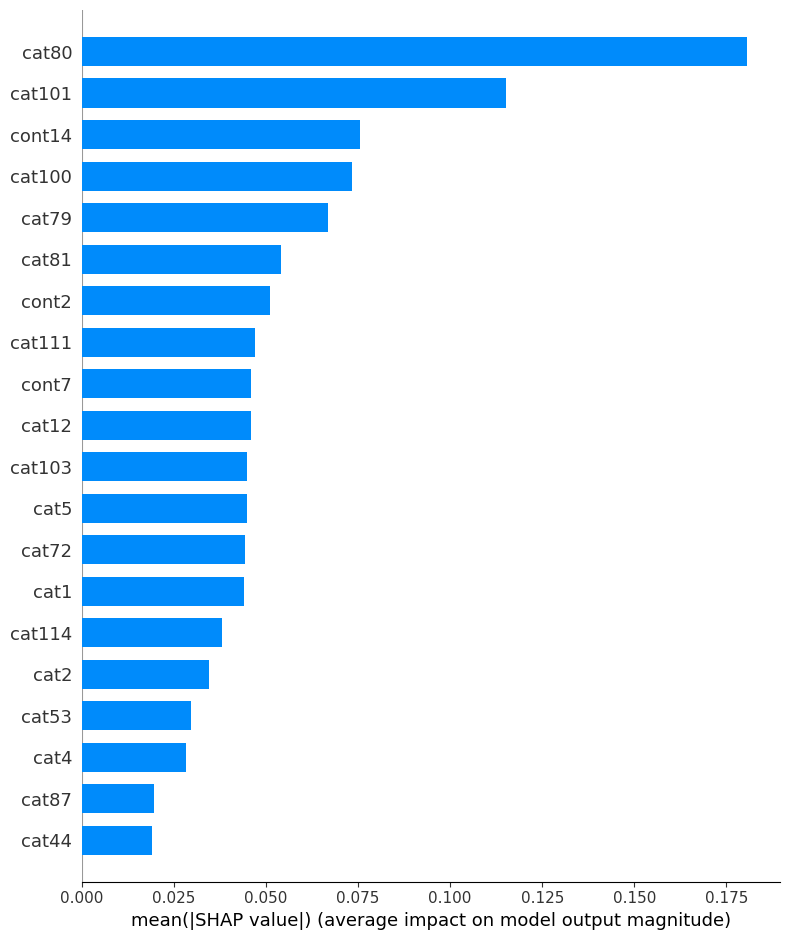

In [20]:
# Bar plot - mean absolute SHAP value per feature
plt.figure()
shap.summary_plot(shap_values, X_valid, plot_type="bar", max_display=20, show=False)
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

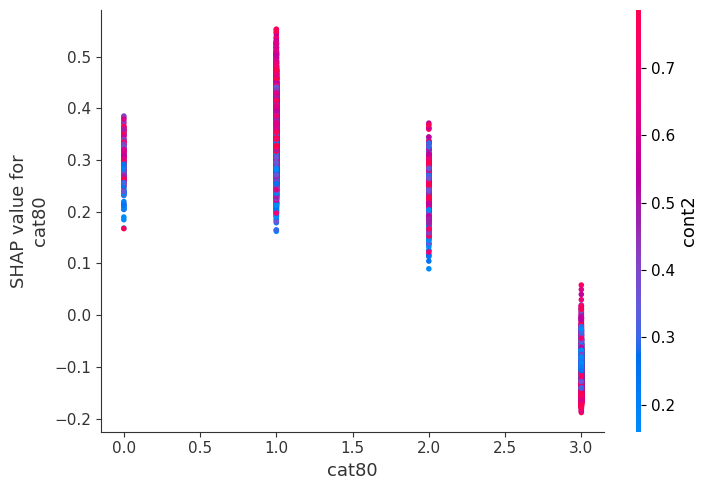

In [21]:
# Dependence plot for cat80 - top categorical feature by SHAP importance
plt.figure()
shap.dependence_plot("cat80", shap_values, X_valid, show=False)
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/shap_dependence_cat80.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

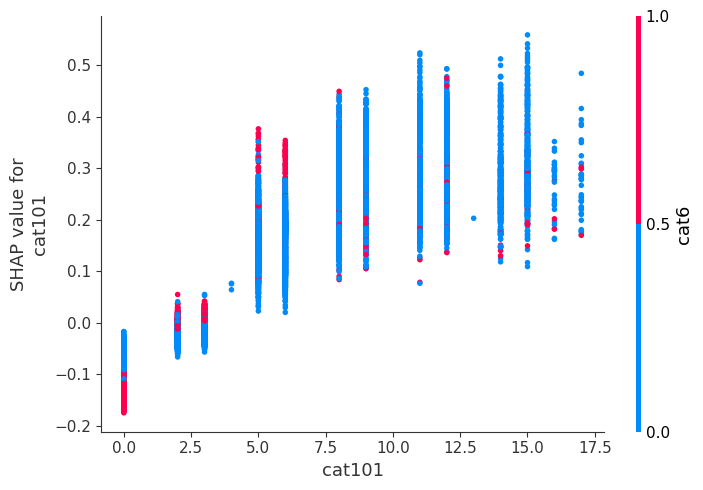

In [22]:
# Dependence plot for cat101 - second most important categorical feature
plt.figure()
shap.dependence_plot("cat101", shap_values, X_valid, show=False)
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/shap_dependence_cat101.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

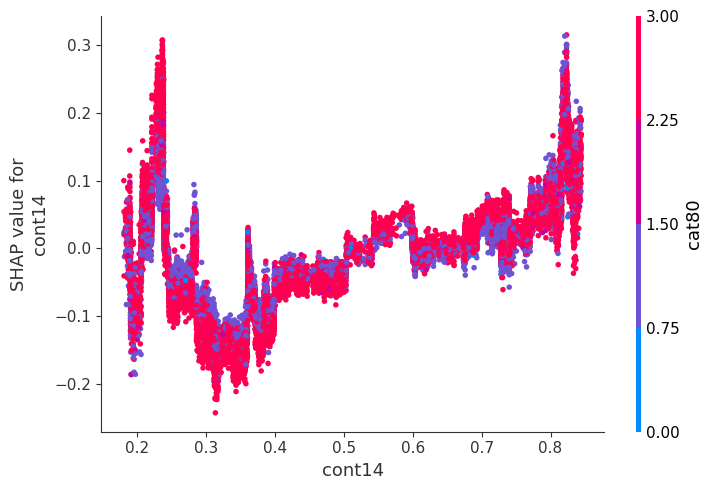

In [23]:
# Dependence plot for cont14 - top continuous feature by SHAP importance
plt.figure()
shap.dependence_plot("cont14", shap_values, X_valid, show=False)
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/shap_dependence_cont14.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
# Create error analysis dataframe for deeper evaluation of model weaknesses
error_df = pd.DataFrame({
    "actual": y_valid_actual,
    "predicted": lgb_pred,
    "error": lgb_pred - y_valid_actual,
    "abs_error": np.abs(lgb_pred - y_valid_actual),
    "pct_error": np.abs(lgb_pred - y_valid_actual) / y_valid_actual * 100
})

print(error_df[["error", "abs_error", "pct_error"]].describe())

              error     abs_error     pct_error
count  37664.000000  37664.000000  37664.000000
mean    -361.900414   1135.162708     47.491177
std     1860.995082   1518.436530     81.114641
min   -59158.715841      0.047275      0.005530
25%     -906.960852    298.974416     15.675481
50%      -26.958110    668.690434     32.484467
75%      531.574207   1393.712770     55.176794
max    16628.288643  59158.715841   6911.504376


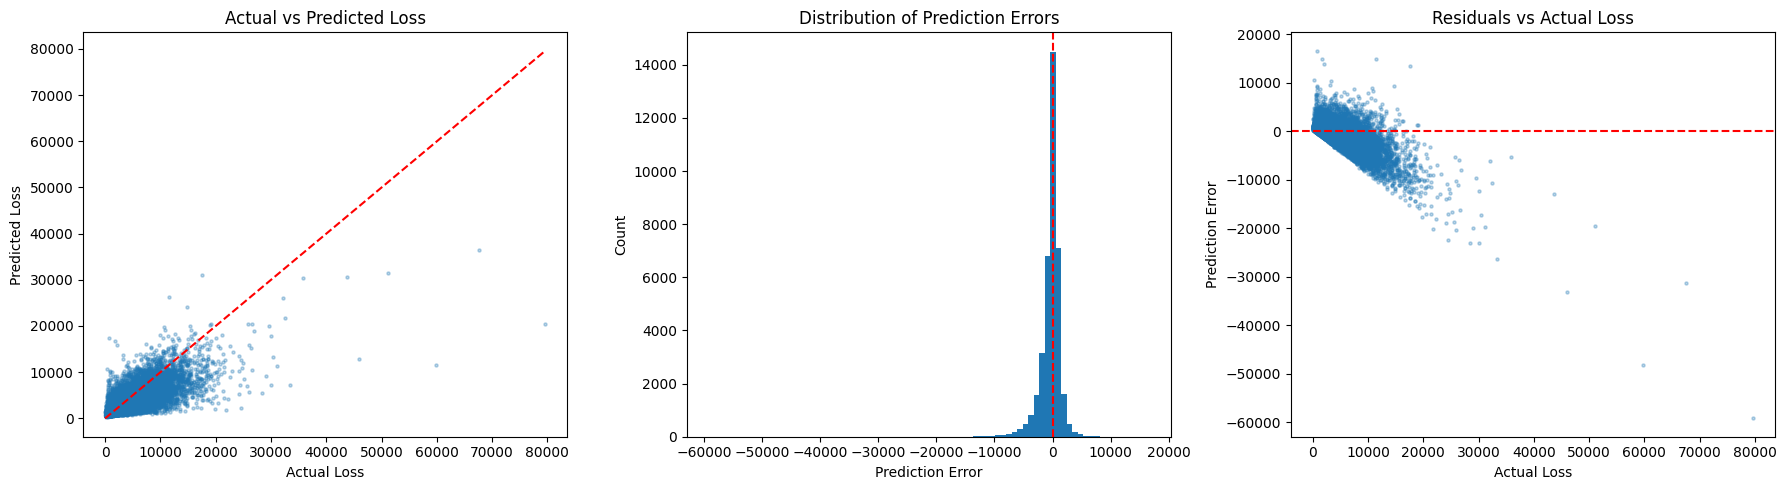

In [25]:
# Three-panel diagnostic:
#   Left:   Actual vs Predicted scatter — ideal is tight diagonal
#   Center: Residual distribution — ideal is centered at zero
#   Right:  (continues below — cell was truncated, complete version below)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(error_df["actual"], error_df["predicted"], alpha=0.3, s=5)
axes[0].plot([0, error_df["actual"].max()], [0, error_df["actual"].max()],
             color="red", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Actual Loss")
axes[0].set_ylabel("Predicted Loss")
axes[0].set_title("Actual vs Predicted Loss")

axes[1].hist(error_df["error"], bins=80, edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Prediction Error")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Prediction Errors")

axes[2].scatter(error_df["actual"], error_df["error"], alpha=0.3, s=5)
axes[2].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[2].set_xlabel("Actual Loss")
axes[2].set_ylabel("Prediction Error")
axes[2].set_title("Residuals vs Actual Loss")

plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# Model systematically underpredicts extreme claims — a known limitation
# High-severity claims are rare in training data, so the model regresses toward the mean
print("Underprediction on high-severity claims (actual > 6401):")
high_sev_errors = error_df[error_df["actual"] >= 6401.74]
print("Mean error:", round(high_sev_errors["error"].mean(), 2))
print("Mean abs error:", round(high_sev_errors["abs_error"].mean(), 2))
print("Count:", len(high_sev_errors))

Underprediction on high-severity claims (actual > 6401):
Mean error: -3237.02
Mean abs error: 3671.99
Count: 3769


In [27]:
# Install MLflow for experiment tracking
!pip install mlflow --quiet
import mlflow
import mlflow.lightgbm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [28]:
# Point MLflow to project directory
mlflow.set_tracking_uri(PROJECT_PATH + "mlruns")
mlflow.set_experiment("allstate_claims_severity")

<Experiment: artifact_location=('/content/drive/MyDrive/Colab '
 'Notebooks/DATA6545/allstate_project/mlruns/836920636767541842'), creation_time=1774452656400, experiment_id='836920636767541842', last_update_time=1774452656400, lifecycle_stage='active', name='allstate_claims_severity', tags={}, trace_location=None, workspace='default'>

In [29]:
# Log all hyperparameters and validation metrics for the primary regressor
with mlflow.start_run(run_name="lgbm_regressor"):

    mlflow.log_param("model_type", "LGBMRegressor")
    mlflow.log_param("n_estimators", 1000)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("num_leaves", 63)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("target_transform", "log1p")
    mlflow.log_param("encoding", "label_encoding")
    mlflow.log_param("train_rows", X_train.shape[0])
    mlflow.log_param("valid_rows", X_valid.shape[0])

    mlflow.log_metric("val_mae", lgb_mae)
    mlflow.log_metric("val_rmse", lgb_rmse)
    mlflow.log_metric("val_r2", lgb_r2)
    mlflow.log_metric("cv_mean_mae", 1145.91)
    mlflow.log_metric("cv_std_mae", 7.95)
    mlflow.log_metric("cv_mean_r2", 0.5519)
    mlflow.log_metric("high_sev_mean_error", -3237.02)
    mlflow.log_metric("high_sev_mean_abs_error", 3671.99)

    mlflow.log_artifact(PROJECT_PATH + "figures/shap_summary_bar.png")
    mlflow.log_artifact(PROJECT_PATH + "figures/shap_summary_dot.png")
    mlflow.log_artifact(PROJECT_PATH + "figures/error_analysis.png")
    mlflow.log_artifact(PROJECT_PATH + "models/lgbm_regressor.joblib")

    print("Run logged successfully.")

Run logged successfully.


In [30]:
# Log classifier run
with mlflow.start_run(run_name="lgbm_classifier"):

    mlflow.log_param("model_type", "LGBMClassifier")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("severity_threshold", 6401.74)
    mlflow.log_param("threshold_percentile", 0.90)
    mlflow.log_param("classification_threshold", round(float(optimal_threshold), 4))
    mlflow.log_param("threshold_method", "Youden's J")

    mlflow.log_metric("val_auc_roc", auc)
    mlflow.log_metric("high_sev_precision", clf_precision_opt)
    mlflow.log_metric("high_sev_recall", clf_recall_opt)
    mlflow.log_metric("high_sev_f1", clf_f1_opt)
    mlflow.log_metric("overall_accuracy", 0.83)

    mlflow.log_artifact(PROJECT_PATH + "models/lgbm_classifier.joblib")

    print("Run logged successfully.")

Run logged successfully.


In [31]:
# Log Ridge baseline results for comparison
with mlflow.start_run(run_name="ridge_baseline"):

    mlflow.log_param("model_type", "Ridge")
    mlflow.log_param("alpha", 1.0)
    mlflow.log_param("target_transform", "log1p")
    mlflow.log_param("encoding", "one_hot_encoding")

    mlflow.log_metric("val_mae", 1244.68)
    mlflow.log_metric("val_rmse", 2185.06)
    mlflow.log_metric("val_r2", 0.4149)

    print("Run logged successfully.")

Run logged successfully.


In [32]:
# Log Random Forest results
with mlflow.start_run(run_name="random_forest"):

    mlflow.log_param("model_type", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 150)
    mlflow.log_param("max_depth", 12)
    mlflow.log_param("target_transform", "log1p")
    mlflow.log_param("encoding", "one_hot_encoding")

    mlflow.log_metric("val_mae", 1223.44)
    mlflow.log_metric("val_rmse", 2055.23)
    mlflow.log_metric("val_r2", 0.4823)

    print("Run logged successfully.")

Run logged successfully.


In [33]:
# Segment validation predictions into four severity tiers
error_df["severity_tier"] = pd.cut(
    error_df["actual"],
    bins=[0, 1000, 3000, 6401.74, np.inf],
    labels=["Low", "Moderate", "High", "Extreme"]
)

tier_summary = error_df.groupby("severity_tier", observed=True).agg(
    claim_count=("actual", "count"),
    mean_actual_loss=("actual", "mean"),
    mean_predicted_loss=("predicted", "mean"),
    mean_abs_error=("abs_error", "mean"),
    mean_pct_error=("pct_error", "mean"),
    median_actual_loss=("actual", "median")
).round(2)

print(tier_summary)

               claim_count  mean_actual_loss  mean_predicted_loss  \
severity_tier                                                       
Low                   6726            722.81              1339.38   
Moderate             17830           1836.83              1987.39   
High                  9339           4327.84              3443.18   
Extreme               3769           9557.63              6320.61   

               mean_abs_error  mean_pct_error  median_actual_loss  
severity_tier                                                      
Low                    627.77          103.68              744.56  
Moderate               632.77           36.03             1759.94  
High                  1435.96           33.07             4166.32  
Extreme               3671.99           37.17             8471.83  


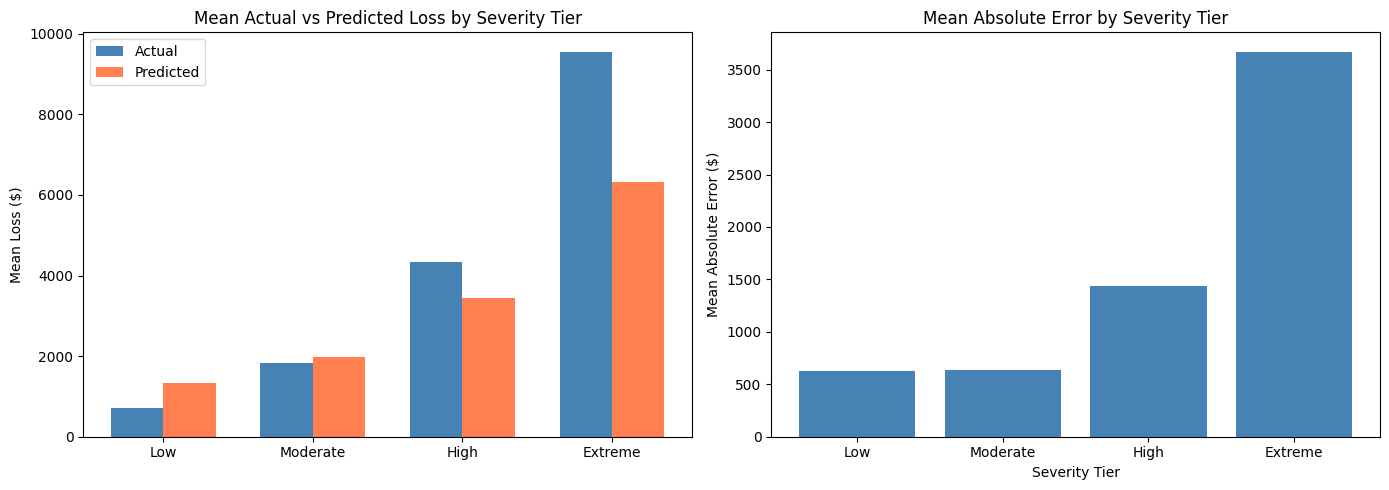

In [34]:
# Visual comparison of actual vs. predicted loss by severity tier
# Right graph shows percent error
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_labels = tier_summary.index.tolist()
x = np.arange(len(tier_labels))
width = 0.35

axes[0].bar(x - width/2, tier_summary["mean_actual_loss"], width, label="Actual", color="steelblue")
axes[0].bar(x + width/2, tier_summary["mean_predicted_loss"], width, label="Predicted", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(tier_labels)
axes[0].set_title("Mean Actual vs Predicted Loss by Severity Tier")
axes[0].set_ylabel("Mean Loss ($)")
axes[0].legend()

axes[1].bar(tier_labels, tier_summary["mean_abs_error"], color="steelblue")
axes[1].set_title("Mean Absolute Error by Severity Tier")
axes[1].set_ylabel("Mean Absolute Error ($)")
axes[1].set_xlabel("Severity Tier")

plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/severity_tier_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

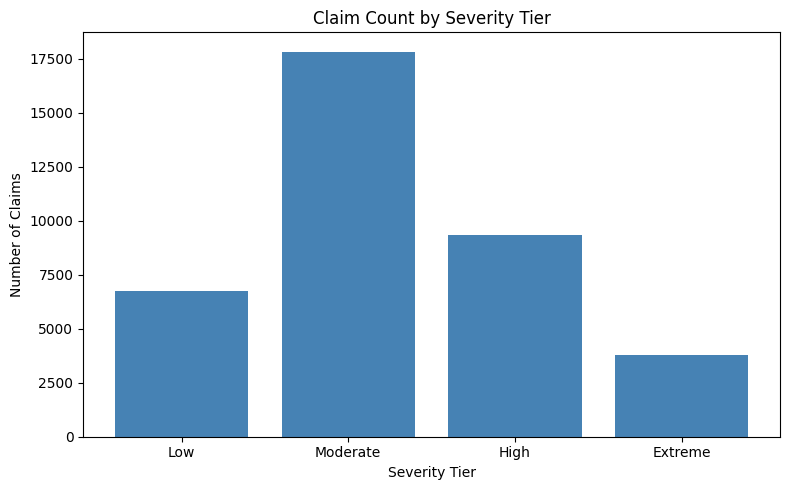

In [35]:
# Most claims fall in low/moderatw tiers - class imbalance affects Extreme tier performance
tier_counts = error_df["severity_tier"].value_counts().reindex(["Low", "Moderate", "High", "Extreme"])

plt.figure(figsize=(8, 5))
plt.bar(tier_counts.index, tier_counts.values, color="steelblue")
plt.title("Claim Count by Severity Tier")
plt.xlabel("Severity Tier")
plt.ylabel("Number of Claims")
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/severity_tier_counts.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
# Summary table of all three models
final_results = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest", "LightGBM"],
    "MAE":   [1244.68, 1223.44, round(lgb_mae, 2)],
    "RMSE":  [2185.06, 2055.23, round(lgb_rmse, 2)],
    "R2":    [0.4149, 0.4823,   round(lgb_r2, 4)],
    "CV MAE": [None, None, round(float(np.mean(fold_maes)), 2)],
    "CV Std": [None, None, round(float(np.std(fold_maes)), 2)]
})

print(final_results.to_string(index=False))

           Model     MAE    RMSE     R2  CV MAE  CV Std
Ridge Regression 1244.68 2185.06 0.4149     NaN     NaN
   Random Forest 1223.44 2055.23 0.4823     NaN     NaN
        LightGBM 1135.16 1895.83 0.5595 1145.91    7.95


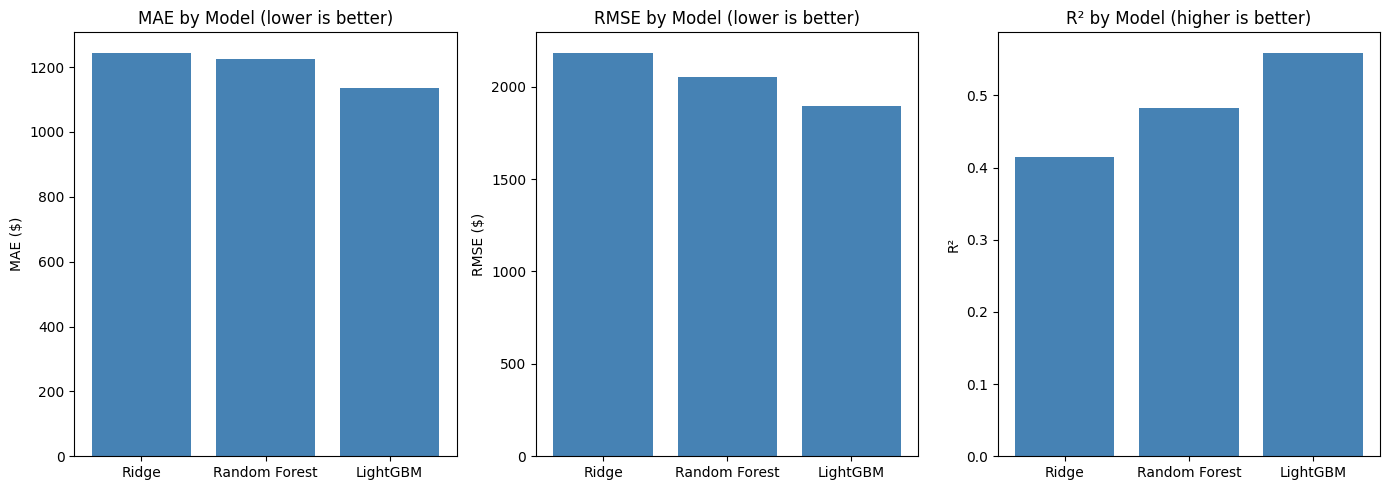

In [37]:
# Visual comparison across all three models
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models = ["Ridge", "Random Forest", "LightGBM"]
maes  = [1244.68, 1223.44, lgb_mae]
rmses = [2185.06, 2055.23, lgb_rmse]
r2s   = [0.4149,  0.4823,  lgb_r2]

axes[0].bar(models, maes, color="steelblue")
axes[0].set_title("MAE by Model (lower is better)")
axes[0].set_ylabel("MAE ($)")

axes[1].bar(models, rmses, color="steelblue")
axes[1].set_title("RMSE by Model (lower is better)")
axes[1].set_ylabel("RMSE ($)")

axes[2].bar(models, r2s, color="steelblue")
axes[2].set_title("R² by Model (higher is better)")
axes[2].set_ylabel("R²")

plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
# Apply final LightGBM model to held-out test set and assign severity tiers
test_pred_log = lgb_model.predict(X_test)
test_pred_loss = np.expm1(test_pred_log)

test_predictions = pd.DataFrame({
    "id": test["id"],
    "predicted_loss": test_pred_loss.round(2),
    "severity_tier": pd.cut(
        test_pred_loss,
        bins=[0, 1000, 3000, 6401.74, np.inf],
        labels=["Low", "Moderate", "High", "Extreme"]
    )
})

print(test_predictions.head(10))
print("\nSeverity tier breakdown:")
print(test_predictions["severity_tier"].value_counts())

   id  predicted_loss severity_tier
0   4         1476.94      Moderate
1   6         2062.37      Moderate
2   9        10043.74       Extreme
3  12         6072.07          High
4  15          775.98           Low
5  17         2366.66      Moderate
6  21         1721.74      Moderate
7  28          855.46           Low
8  32         2299.00      Moderate
9  43         3230.21          High

Severity tier breakdown:
severity_tier
Moderate    80756
High        28049
Low          9784
Extreme      6957
Name: count, dtype: int64


In [39]:
# Write test predictions to processed data folder
import os
os.makedirs(PROJECT_PATH + "data/processed/", exist_ok=True)
test_predictions.to_csv(PROJECT_PATH + "data/processed/test_predictions.csv", index=False)
print("Predictions saved.")

Predictions saved.


In [40]:
# Ethical Considerations
ethical_notes = """
ETHICAL CONSIDERATIONS
======================

1. POTENTIAL HARMS
   - Insurers could use predicted severity to deny, delay, or underpay claims.
   - Claimants with predicted low-severity scores may receive less adjuster attention
     even when their actual need is high.

2. BIAS ASSESSMENT
   - The dataset's categorical features (cat1–cat116) are anonymized — we cannot
     verify whether they encode proxies for race, gender, geography, or income.
   - If high-severity predictions correlate with protected characteristics, the
     classifier could systematically disadvantage certain groups.
   - Recommended mitigation: audit model outputs against any available demographic
     breakdowns before production deployment.

3. PRIVACY
   - The Kaggle dataset is fully anonymized with no PII. No raw claimant data is
     stored or transmitted in this project.

4. MISUSE POTENTIAL
   - A severity predictor could be used to profile claimants and selectively
     contest high-cost claims, which may conflict with fair claims handling laws.
   - The high-severity classifier (AUC 0.93) is powerful enough to meaningfully
     alter claim handling workflows — deployment decisions should involve legal review.

5. TRANSPARENCY
   - SHAP values provide feature-level explanations for individual predictions.
   - Affected claimants should have access to an explanation of any automated
     decision that affects their claim outcome.
   - The model has documented limitations on Extreme-tier claims (see error analysis)
     and should not be used as the sole basis for large-claim decisions.
"""

print(ethical_notes)

# Save to file for final report
with open(PROJECT_PATH + "ethical_considerations.txt", "w") as f:
    f.write(ethical_notes)

print("Saved to ethical_considerations.txt")


ETHICAL CONSIDERATIONS

1. POTENTIAL HARMS
   - Insurers could use predicted severity to deny, delay, or underpay claims.
   - Claimants with predicted low-severity scores may receive less adjuster attention
     even when their actual need is high.

2. BIAS ASSESSMENT
   - The dataset's categorical features (cat1–cat116) are anonymized — we cannot
     verify whether they encode proxies for race, gender, geography, or income.
   - If high-severity predictions correlate with protected characteristics, the
     classifier could systematically disadvantage certain groups.
   - Recommended mitigation: audit model outputs against any available demographic
     breakdowns before production deployment.

3. PRIVACY
   - The Kaggle dataset is fully anonymized with no PII. No raw claimant data is
     stored or transmitted in this project.

4. MISUSE POTENTIAL
   - A severity predictor could be used to profile claimants and selectively
     contest high-cost claims, which may conflict with fai

In [41]:
MODEL_PATH = PROJECT_PATH + "models/"

high_sev_threshold = float(train["loss"].quantile(0.90))  # 6401.74

# Rebuild label encoders fitted on combined train+test
combined = pd.concat([train[feature_cols], test[feature_cols]], axis=0)
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(combined[col].astype(str))
    label_encoders[col] = le

metadata = {
    "feat_cols":          feature_cols,
    "cat_cols":           cat_cols,
    "num_cols":           num_cols,
    "high_sev_threshold": high_sev_threshold,
    "tier_boundaries": {
        "low_max":      1000.0,
        "moderate_max": 3000.0,
        "high_max":     high_sev_threshold,
    },
    "val_metrics": {
        "mae":          1135.16,
        "rmse":         1895.83,
        "r2":           0.5595,
        "cv_mean_mae":  1145.91,
        "cv_std_mae":   7.95,
        "auc_roc":      0.9315,
        "precision":    0.72,
        "recall":       0.47,
        "f1":           0.57,
    },
    "dataset": {
        "train_rows":   188318,
        "test_rows":    125546,
        "n_features":   130,
    }
}

joblib.dump(label_encoders, MODEL_PATH + "label_encoders.joblib")
joblib.dump(metadata,       MODEL_PATH + "metadata.joblib")

print("Saved label_encoders.joblib and metadata.joblib")
print(f"High severity threshold: ${high_sev_threshold:,.2f}")
print(f"Encoders saved for {len(label_encoders)} categorical columns")

Saved label_encoders.joblib and metadata.joblib
High severity threshold: $6,401.74
Encoders saved for 116 categorical columns


In [42]:
import os
for f in ["lgbm_regressor.joblib", "lgbm_classifier.joblib", "label_encoders.joblib", "metadata.joblib"]:
    path = MODEL_PATH + f
    exists = os.path.exists(path)
    size_kb = os.path.getsize(path) / 1024 if exists else 0
    print(f"{'OK' if exists else 'MISSING'} {f} ({size_kb:.0f} KB)")

OK lgbm_regressor.joblib (3876 KB)
OK lgbm_classifier.joblib (2599 KB)
OK label_encoders.joblib (30 KB)
OK metadata.joblib (2 KB)


In [45]:
# Export MLflow run summary for version control
import mlflow
import pandas as pd

mlflow.set_tracking_uri(PROJECT_PATH + "mlruns")
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name("allstate_claims_severity")

rows = []
for run in client.search_runs(experiment.experiment_id):
    row = {"run_name": run.data.tags.get("mlflow.runName", run.info.run_id)}
    row.update(run.data.params)
    row.update({f"metric_{k}": v for k, v in run.data.metrics.items()})
    rows.append(row)

summary = pd.DataFrame(rows)
out_path = PROJECT_PATH + "mlflow_run_summary.csv"
summary.to_csv(out_path, index=False)
print(f"Exported {len(rows)} runs to {out_path}")
print(summary.to_string(index=False))

Exported 28 runs to /content/drive/MyDrive/Colab Notebooks/DATA6545/allstate_project/mlflow_run_summary.csv
       run_name            model_type n_estimators max_depth target_transform         encoding  metric_val_mae  metric_val_rmse  metric_val_r2 alpha learning_rate severity_threshold threshold_percentile classification_threshold threshold_method  metric_val_auc_roc  metric_high_sev_precision  metric_high_sev_recall  metric_high_sev_f1  metric_overall_accuracy num_leaves subsample colsample_bytree train_rows valid_rows  metric_cv_mean_mae  metric_cv_std_mae  metric_cv_mean_r2  metric_high_sev_mean_error  metric_high_sev_mean_abs_error
  random_forest RandomForestRegressor          150        12            log1p one_hot_encoding     1223.440000      2055.230000       0.482300   NaN           NaN                NaN                  NaN                      NaN              NaN                 NaN                        NaN                     NaN                 NaN                  

In [46]:
summary_clean = summary.drop_duplicates(subset=["run_name", "model_type"]).reset_index(drop=True)
summary_clean.to_csv(out_path, index=False)
print(f"Cleaned: {len(summary_clean)} runs")
print(summary_clean[["run_name", "model_type", "metric_val_mae", "metric_val_rmse", "metric_val_r2"]].to_string(index=False))

Cleaned: 4 runs
       run_name            model_type  metric_val_mae  metric_val_rmse  metric_val_r2
  random_forest RandomForestRegressor     1223.440000      2055.230000       0.482300
 ridge_baseline                 Ridge     1244.680000      2185.060000       0.414900
lgbm_classifier        LGBMClassifier             NaN              NaN            NaN
 lgbm_regressor         LGBMRegressor     1135.162708      1895.832971       0.559515


In [50]:
import pandas as pd
import numpy as np
import joblib

PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/DATA6545/allstate_project/"

# Reload test data
test = pd.read_csv(PROJECT_PATH + "data/raw/test.csv")

# Load artifacts
regressor      = joblib.load(PROJECT_PATH + "models/lgbm_regressor.joblib")
classifier     = joblib.load(PROJECT_PATH + "models/lgbm_classifier.joblib")
label_encoders = joblib.load(PROJECT_PATH + "models/label_encoders.joblib")
metadata       = joblib.load(PROJECT_PATH + "models/metadata.joblib")

FEAT_COLS          = metadata["feat_cols"]
CAT_COLS           = metadata["cat_cols"]
NUM_COLS           = metadata["num_cols"]
HIGH_SEV_THRESHOLD = metadata["high_sev_threshold"]

# Encode — vectorized
test_encoded = test[FEAT_COLS].copy()
for col in CAT_COLS:
    le = label_encoders[col]
    classes_map = {c: i for i, c in enumerate(le.classes_)}
    test_encoded[col] = test_encoded[col].astype(str).map(classes_map).fillna(0).astype(int)

# Inference
log_preds = regressor.predict(test_encoded)
losses    = np.expm1(log_preds).round(2)
probs     = classifier.predict_proba(test_encoded)[:, 1].round(4)
flags     = (losses >= HIGH_SEV_THRESHOLD).astype(bool)

def get_tier(loss):
    if loss < 1000:                 return "Low"
    elif loss < 3000:               return "Moderate"
    elif loss < HIGH_SEV_THRESHOLD: return "High"
    return "Extreme"

test_predictions_full = pd.DataFrame({
    "id":                        test["id"],
    "predicted_loss":            losses,
    "high_severity_probability": probs,
    "high_severity_flag":        flags,
    "severity_tier":             [get_tier(l) for l in losses],
})

test_predictions_full.to_csv(
    PROJECT_PATH + "data/processed/test_predictions_full.csv", index=False
)
print(f"Saved {len(test_predictions_full):,} rows")
print(test_predictions_full.head(10))

Saved 125,546 rows
   id  predicted_loss  high_severity_probability  high_severity_flag  \
0   4         1476.94                     0.0076               False   
1   6         2062.37                     0.0111               False   
2   9        10043.74                     0.9612                True   
3  12         6072.07                     0.4326               False   
4  15          775.98                     0.0011               False   
5  17         2366.66                     0.0042               False   
6  21         1721.74                     0.0140               False   
7  28          855.46                     0.0000               False   
8  32         2299.00                     0.0135               False   
9  43         3230.21                     0.0633               False   

  severity_tier  
0      Moderate  
1      Moderate  
2       Extreme  
3          High  
4           Low  
5      Moderate  
6      Moderate  
7           Low  
8      Moderate  
9       